In [69]:
# Jack Farrell
# Reinforcement Learning
# Pset 3 Problem 1 Monte Carlo Prediction and Control
# 6Jul26

# Domain: Blackjack (Gymnasium Blackjack-v1)
# hand: (player's current sum, dealer's showing card, usable ace)
# Actions: hit (1), stick (0)
# Reward: +1 win, 0 draw, -1 loss; only at terminal
# Discount: γ = 1.0 (episodic, undiscounted)

# AI Usage: In addtion to general debugging, I used ChatGPT to help implement the Blackjack-v1 environment and understand how to access the state, action, reward, etc. I also used it to aid with the heat map graphs.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make("Blackjack-v1", sab=True)    # Build Blackjack-v1 environment

### Monte Carlo Policy hit if under 20, otherwise stick (Part C)

In [70]:
def policy(hand):
    player_sum, dealer_card, usable_ace = hand

    if player_sum >= 20:
        # Stick
        return 0
    else:
        # Hit
        return 1

### Set up first visit Monte Carlo function (Part C)

In [71]:
def first_visit_blackjack(gamma, episodes):
    # Initialize blank placeholders for V(St) and N(St)
    V = {}
    N = {}
    
    # Iterate for number of episodes
    for episodes in range(episodes):
        # Resets episode and starts a new game
        hand, info = env.reset()
        episode = []
        terminated = False
        truncated = False

        # Perform action until hand terminates at 21 or bust
        while not (terminated or truncated):
            action = policy(hand)
            new_hand, reward, terminated, truncated, info = env.step(action)
            episode.append((hand, action, reward))

            # Update hand for next iteration
            hand = new_hand

        # Caluclate Gt
        G = 0
        visited_hands = set()

        # Caluclates Gt backwards from the last available index
        for hand, action, reward in reversed(episode):
            G = gamma * G + reward

            if hand not in visited_hands:
                visited_hands.add(hand)

                # sets initial conditions to zero
                if hand not in N:
                    N[hand] = 0
                    V[hand] = 0

            # Update N(hand) and peform MC update of V(hand)
            N[hand] += 1
            V[hand] += 1/N[hand] * (G - V[hand])

    return V


### Heat map graph function (Part C)

In [72]:
def plot_heatmaps(V):
    # Set up range of numbers to search the Values from MC and graph on heatmap
    player_sums = range(12, 22)     # Set lower bound to 12 as one would always hit on 11 without fear of busting
    dealer_cards = range(1, 11)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, usable_ace in zip(axes, [False, True]):

        heatmap = np.zeros((len(player_sums), len(dealer_cards)))   # establishes heatmap matrix

        # Iterates through player sums and dealer cards checking against V from MC to add to the heatmap
        for i, player_sum in enumerate(player_sums):
            for j, dealer_card in enumerate(dealer_cards):

                hand = (player_sum, dealer_card, usable_ace)

                if hand in V:  # adds hand to heatmap
                    heatmap[i, j] = V[hand]
                else:   # stores hand here as NaN if not observed
                    heatmap[i, j] = np.nan

        im = ax.imshow(
            heatmap,
            origin="lower",
            aspect="auto"
        )

        ax.set_title(f"Usable Ace = {usable_ace}")
        ax.set_xlabel("Dealer Card")
        ax.set_ylabel("Player Sum")

        ax.set_xticks(np.arange(len(dealer_cards)))
        ax.set_xticklabels(dealer_cards)

        ax.set_yticks(np.arange(len(player_sums)))
        ax.set_yticklabels(player_sums)

        fig.colorbar(im, ax=ax, label="V(s)")


    plt.tight_layout()
    plt.show()
    

### Call First-visit Monte Carlo function and run experiment 500,000 times (Part C)

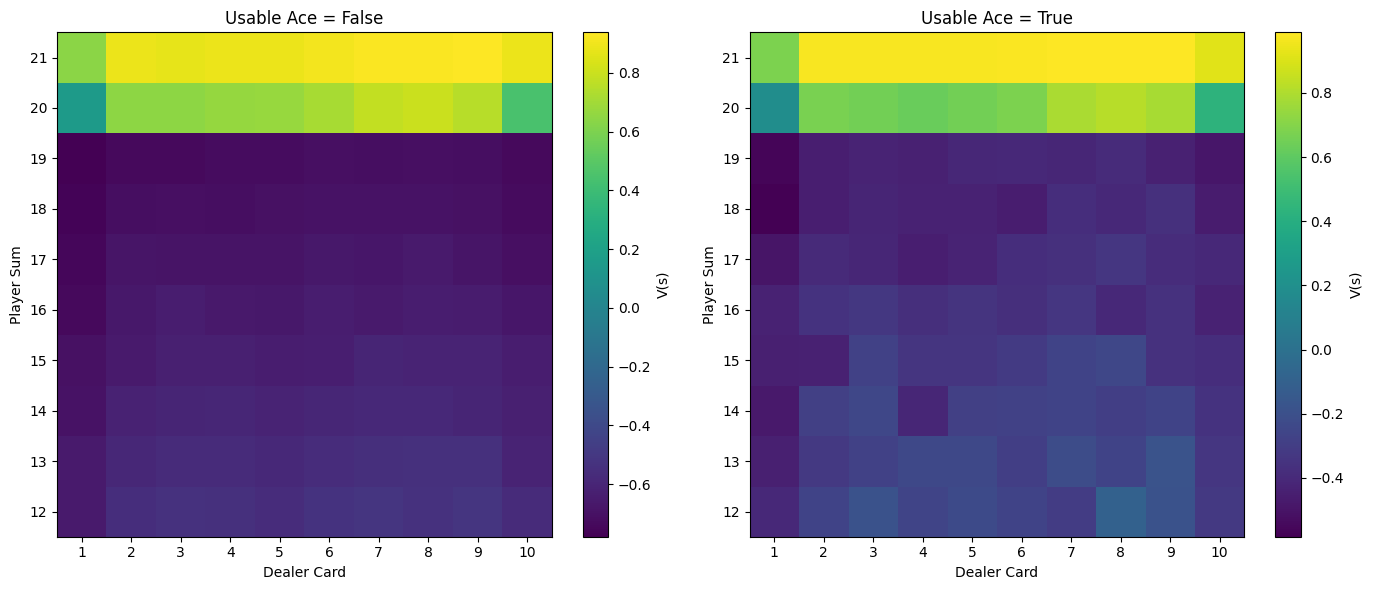

In [73]:
gamma = 1
episodes = 500000

V = first_visit_blackjack(gamma, episodes)

plot_heatmaps(V)


### ε- soft policy first visit Monte Carlo (Part D)

In [74]:
def epsilon_soft_policy(hand, Q, epsilon):
    actions = [0, 1]  # [stick, hit]
    m = len(actions)

    # Check Q-values and find the greedy action
    q_values = [Q.get((hand, action), 0) for action in actions]        # Get Q-values for both actions
    greedy_action = np.argmax(q_values)                                # Find greedy action

    # Create epsilon-soft probabilities for exploring and exploitive action
    probabilities = np.ones(m) * (epsilon / m)      # Explore
    probabilities[greedy_action] += (1 - epsilon)   # Exploit

    # Pick action based on probability defined by ε
    action = np.random.choice(actions, p=probabilities)

    return action

### Monte Carlo Control with  ε-soft policies ε=0.1 (Part D)

In [75]:
def epsilon_soft_first_visit_blackjack(gamma, epsilon, episodes):
    # Initialize blank placeholders for V(St) and N(St)
    Q = {}
    N = {}
    
    # Iterate for number of episodes
    for episodes in range(episodes):
        # Resets episode and starts a new game
        hand, info = env.reset()
        episode = []
        terminated = False
        truncated = False

        # Perform action until hand terminates at 21 or bust
        while not (terminated or truncated):
            action = epsilon_soft_policy(hand, Q, epsilon)
            new_hand, reward, terminated, truncated, info = env.step(action)
            episode.append((hand, action, reward))

            # Update hand for next iteration
            hand = new_hand

        # Caluclate Gt
        G = 0
        visited_hand_actions = set()


        # Caluclates Gt backwards from the last available index
        for hand, action, reward in reversed(episode):
            G = gamma * G + reward
            hand_action = (hand, action)

            if hand_action not in visited_hand_actions:
                visited_hand_actions.add(hand_action)

                # sets initial conditions to zero
                if hand_action not in Q:
                    N[hand_action] = 0
                    Q[hand_action] = 0

                # Update N(hand) and peform MC update of Q(hand)
                N[hand_action] += 1
                Q[hand_action] += 1/N[hand_action] * (G - Q[hand_action])

    return Q


### Plot for ε-soft policy

In [76]:
def plot_epsilon_soft_policy(policy):

    # Set up range of numbers to search the Values from MC and graph on grid
    player_sums = range(12, 22)     # Set lower bound to 12 as one would always hit on 11 without fear of busting
    dealer_cards = range(1, 11)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, usable_ace in zip(axes, [False, True]):

        grid = np.zeros((len(player_sums), len(dealer_cards)))   # establishes grid matrix

        # Iterates through player sums and dealer cards checking against V from MC to add to the grid
        for i, player_sum in enumerate(player_sums):
            for j, dealer_card in enumerate(dealer_cards):

                hand = (player_sum, dealer_card, usable_ace)

                if hand in policy:  # adds hand to grid
                    grid[i, j] = policy[hand]

        # Display background
        ax.imshow(grid,
                  origin="lower",
                  aspect="auto",
                  cmap="coolwarm",
                  vmin=0,
                  vmax=1)

        # Write H or S in every visited cell
        for i in range(len(player_sums)):
            for j in range(len(dealer_cards)):

                if not np.isnan(grid[i, j]):

                    action = "S" if grid[i, j] == 0 else "H"

                    ax.text(j,
                            i,
                            action,
                            ha="center",
                            va="center",
                            color="black",
                            fontsize=10)

        ax.set_title(f"Learned Policy: Usable Ace = {usable_ace}")
        ax.set_xlabel("Dealer Card")
        ax.set_ylabel("Player Sum")

        ax.set_xticks(np.arange(len(dealer_cards)))
        ax.set_xticklabels(dealer_cards)

        ax.set_yticks(np.arange(len(player_sums)))
        ax.set_yticklabels(player_sums)

    plt.tight_layout()
    plt.show()

### Call First-visit ε-soft Monte Carlo function and run experiment 500,000 times (Part D)

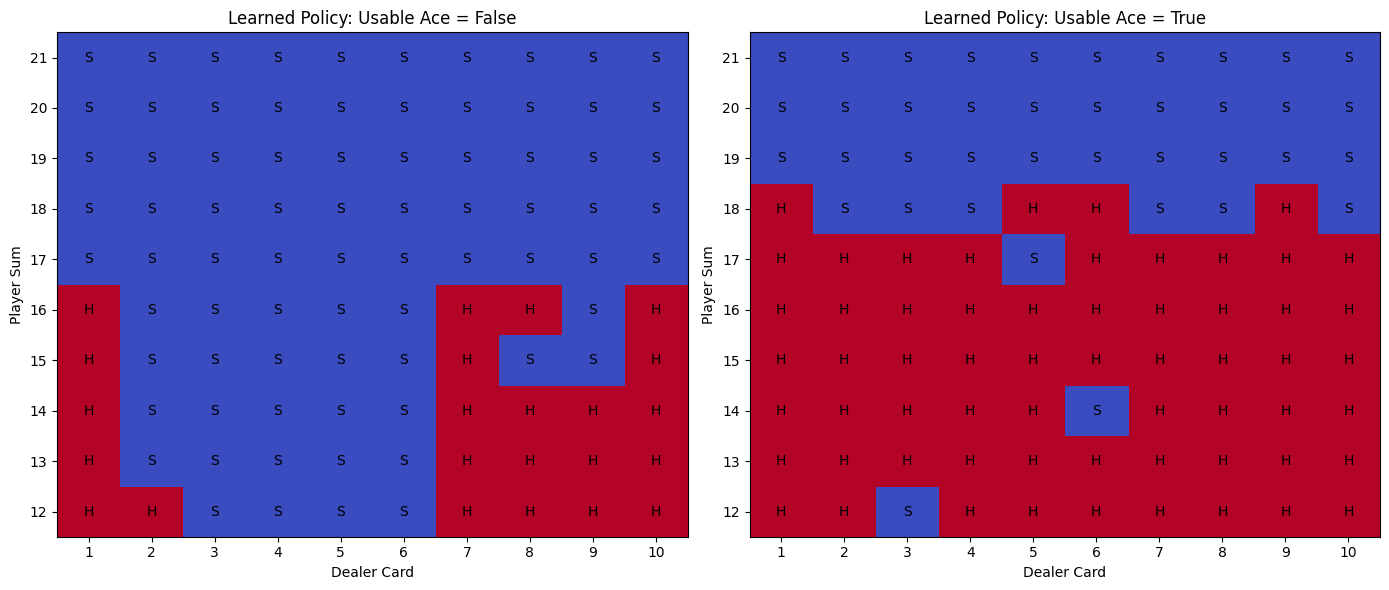

In [77]:
gamma = 1
epsilon = 0.1
episodes = 500000

Q = epsilon_soft_first_visit_blackjack(gamma, epsilon, episodes)

MC_epsilon_soft_policy = {}

# Set up policy from Q values
for (hand, action), value in Q.items():
    stick = Q.get((hand, 0), 0)
    hit = Q.get((hand, 1), 0)

    if stick >= hit:
        MC_epsilon_soft_policy[hand] = 0      # Stick
    else:
        MC_epsilon_soft_policy[hand] = 1      # Hit

plot_epsilon_soft_policy(MC_epsilon_soft_policy)

### Part D Discussion
The established policy in part c was rather rudimentary, hit if less than 20. Which shows to have been punishing for almost every state where the player did not already have 20 or 21, resulting in a negative V(s). The learned policy in part d; however, for the no usable ace, would not hit above 16 and for the usable ace would seldom hit above 17, playing more conservatively than the overly aggressive policy in c. Interestingly in the case where the player does not have usable ace, it would stand for every case where the dealer showed a 3 thru 6. In the case where the player did not have a usable ace but the dealer was showing one, the player would hit up until they were showing 16 before standing. The strategy for no usable ace tends to be the most conservative because of the fac that it stands for any hand 12 or more where the dealer is showing 3-6, arguably because of the unknown of where the aces are and the likelihood of drawing a higher card. The lower known card of the dealer in this case may allow them to hit more and win against the player.

### Part E Discussion
First-visit MC gives an unbiased estimate of V_pi where every visit MC would not because for any given hand of blackjack, you can never visit the same state twice in one episode. For each hand you play, every time you hit, the state changes. The choice to stand is terminal, so the policy would stop updating anyway. In thoery, they should provide the same policy as an every visit algorithm can still only visit a state once per episode. What this code does not consider is the case where a duplicate card is drawn and the player would split. In this case, a repeated card would negatively affect the every visit policy.

If the exploration policy in part d did not have a non-zero probability for every action, there is a chance certain states would never be reached. For the times where the epsilon was zero, the policy would only exploit and may miss some states along the way. This could be mitigated by perfroming more episodes, but hte learned policy would skew futther over this time as well.

I would prefer the TD method in the case where I get a duplicate card and have to split the hand, which again is a case that was not considered in this assignment. The TD method would be able to reevaluate on the spot where MC would have to wait until the end of the episode to determine what may have been teh proper action. TD's learnig could account for the appearance of multiple of the same card, where the player would ideally split thie hand.

I woudl prefer the MC method as a way to look at an overview of the game as a whole to determine general rules for playing. Once simulated, it would serve as a good rule of thumb for playing, where TD would be useful for live updates mid game.